In [1]:
from constraints import get_experiment_folder, get_data_folder, show_torch_image, show_torch_mask
from constraints.datatools.datasets import CachedArtificalDataset, artificial_mask_to_label_map
from pathlib import Path
from constraints.losses_metrics import does_violation_occur_with_wall

import torch
import pytorch_lightning as pl
FOLDER = get_experiment_folder(Path("ex4")/"affine_def")
DATA =get_data_folder() / "artificial" / "custom" / "affine_deformed"/"trn"

In [2]:
ds = CachedArtificalDataset(DATA)

torch.Size([1, 256, 256]) torch.Size([4, 256, 256]) torch.Size([4, 256, 256])


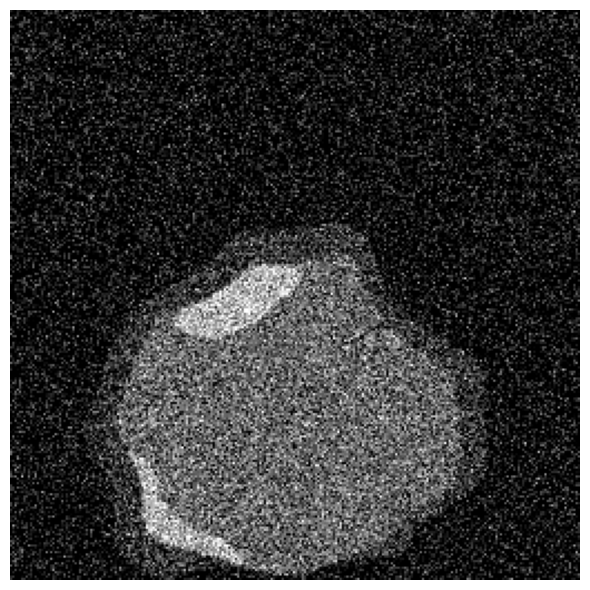

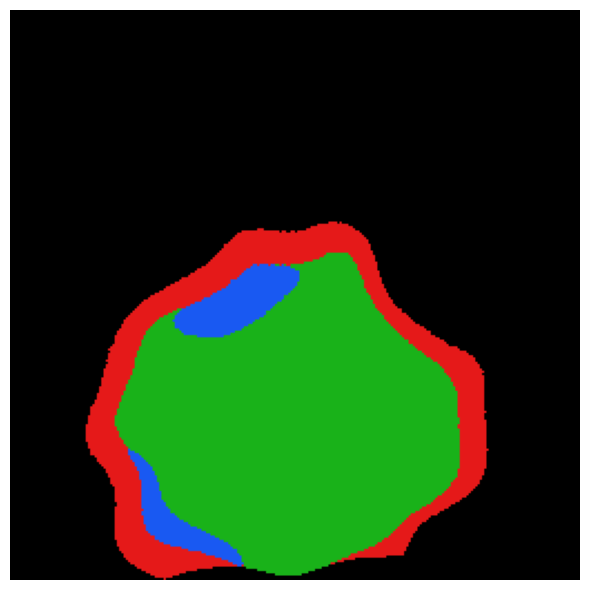

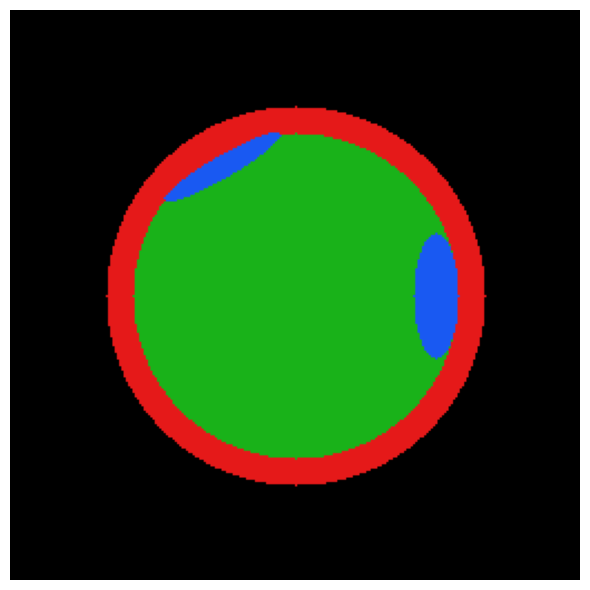

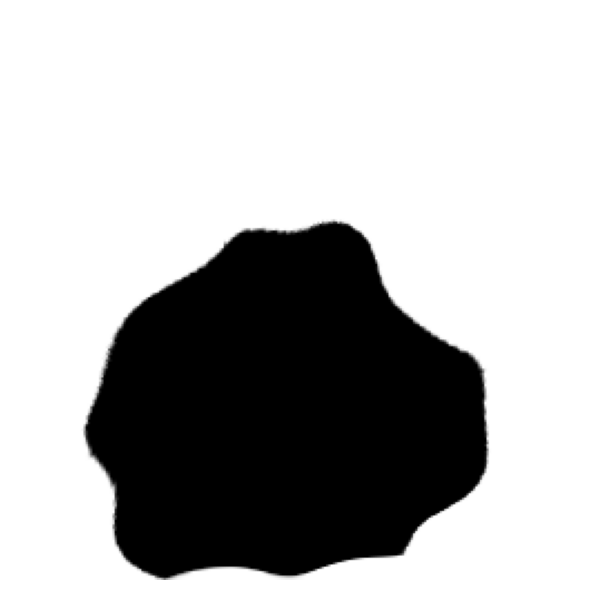

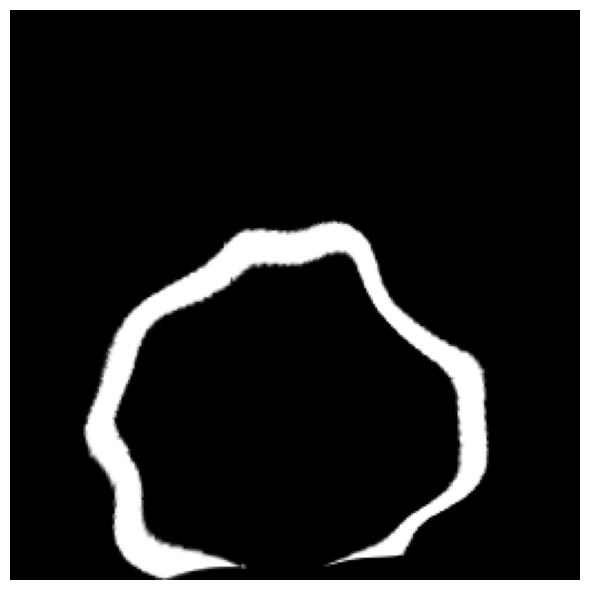

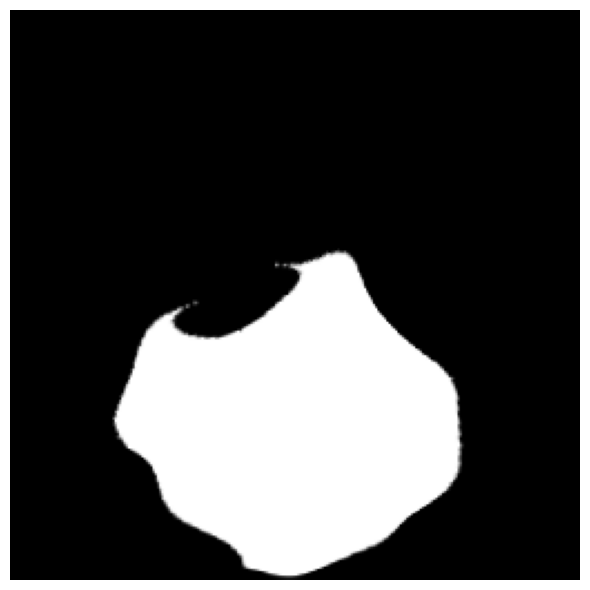

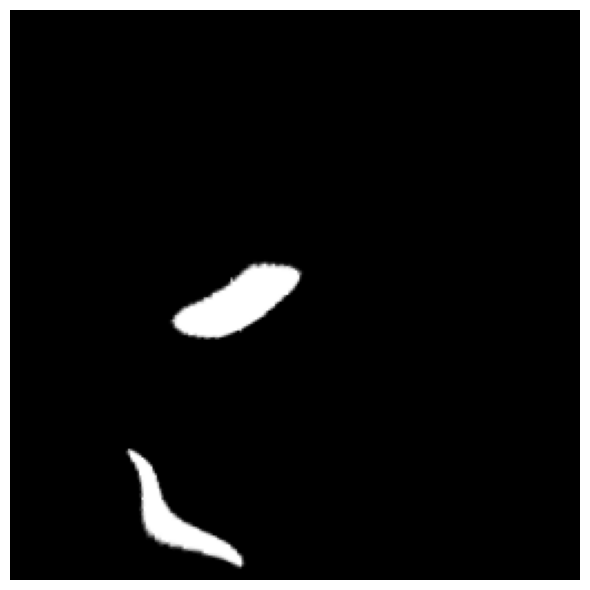

In [3]:
el = ds[0]
print(el["image"].shape, el["mask"].shape, el["template"].shape)
show_torch_image(el["image"],cmap="gray")
show_torch_mask(el["mask"])
show_torch_mask(el["template"])
show_torch_image(el["mask"][0],cmap="gray")
show_torch_image(el["mask"][1],cmap="gray")
show_torch_image(el["mask"][2],cmap="gray")
show_torch_image(el["mask"][3],cmap="gray")

In [4]:
el['mask'].shape

torch.Size([4, 256, 256])

In [5]:
for i in range(len(ds)):
    el = ds[i]
    b,info =  does_violation_occur_with_wall(artificial_mask_to_label_map(el['mask']),check_wall_integrity=False)
    if b:
        print(f"Violation occurs in sample {i}")
        print(f"Info: {info}")
        show_torch_mask(el["mask"])

# Check datasets for correctness

In [6]:
from constraints.losses_metrics.constraint_function import does_violation_occur